In [2]:
#: Carga de librerías --------------------------------------------------
import pandas as pd
import os
import re
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import pydicom
from pydicom.errors import InvalidDicomError
import numpy as np

In [3]:
# Carga y limpieza de datos -------------------------------------------
# Cargamos datasets
path = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset'
image_dir = os.path.join(path, 'jpeg')
meta_data = pd.read_csv(os.path.join(path, 'csv/meta.csv'))
di_data = pd.read_csv(os.path.join(path, 'csv/dicom_info.csv'))

cropped_images = di_data[di_data['SeriesDescription'] == 'cropped images']['image_path']
full_mammo_images = di_data[di_data['SeriesDescription'] == 'full mammogram images']['image_path']
ROI_mask_images = di_data[di_data['SeriesDescription'] == 'ROI mask images']['image_path']

# Amoldamos los paths a nuestra organización de directorios
cropped_images = cropped_images.str.replace('CBIS-DDSM/jpeg', image_dir, regex=False)
full_mammo_images = full_mammo_images.str.replace('CBIS-DDSM/jpeg', image_dir, regex=False)
ROI_mask_images = ROI_mask_images.str.replace('CBIS-DDSM/jpeg', image_dir, regex=False)

# Creamos diccionarios para poder después asignar el camino correcto
full_mammo_images_dict = dict(zip(full_mammo_images.apply(lambda x: x.split('/')[5]), full_mammo_images))
cropped_images_dict = dict(zip(cropped_images.apply(lambda x: x.split('/')[5]), cropped_images))
ROI_mask_images_dict = dict(zip(ROI_mask_images.apply(lambda x: x.split('/')[5]), ROI_mask_images))

# Cargamos los datasets
cal_test_data = pd.read_csv(os.path.join(path, 'csv/calc_case_description_test_set.csv'))
mass_test_data = pd.read_csv(os.path.join(path, 'csv/mass_case_description_test_set.csv'))
cal_train_data = pd.read_csv(os.path.join(path, 'csv/calc_case_description_train_set.csv'))
mass_train_data = pd.read_csv(os.path.join(path, 'csv/mass_case_description_train_set.csv'))

# Homogeneizamos los nombres de las columnas
mass_test = mass_test_data.rename(columns=lambda x: re.sub(r' ', '_', x))
mass_train = mass_train_data.rename(columns=lambda x: re.sub(r' ', '_', x))
cal_train = cal_train_data.rename(columns=lambda x: re.sub(r' ', '_', x))
cal_test = cal_test_data.rename(columns=lambda x: re.sub(r' ', '_', x))

In [4]:
# Buscamos la clave primaria en el string y lo emparejamos con su dirección
def fix_image_path(data):
    for i in range(len(data)):
        # Update full mammogram image path
        img_name = data.iloc[i, 11].split("/")[2]
        data.iat[i, 11] = full_mammo_images_dict.get(img_name, data.iat[i, 11])

        # Update cropped image path
        img_name = data.iloc[i, 12].split("/")[2]
        data.iat[i, 12] = cropped_images_dict.get(img_name, data.iat[i, 12])

        # Update ROI mask image path
        img_name = data.iloc[i, 13].split("/")[2]
        data.iat[i, 13] = ROI_mask_images_dict.get(img_name, data.iat[i, 13])

    return data

# Aplicamos las funciones
mass_test_data = fix_image_path(mass_test)
mass_train_data = fix_image_path(mass_train)

In [5]:
# Comprobamos que sea correcto
img_name = mass_test_data['ROI_mask_file_path'][0]
print(img_name)

/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.30820586311062570442302321942433426184/1-083.jpg


Mostramos imágenes:
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.245063149211255120613007755642780114172/1-271.jpg
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.85952214611170506017891429690540035518/1-100.jpg
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.22131189612893294827907969600765582967/1-101.jpg
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.239949064412092068706566726490415129934/1-102.jpg
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.215081818713600536113960661873725083371/1-103.jpg
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.30820586311062570442302321942433426184/1-083.jpg
Trying to read: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1

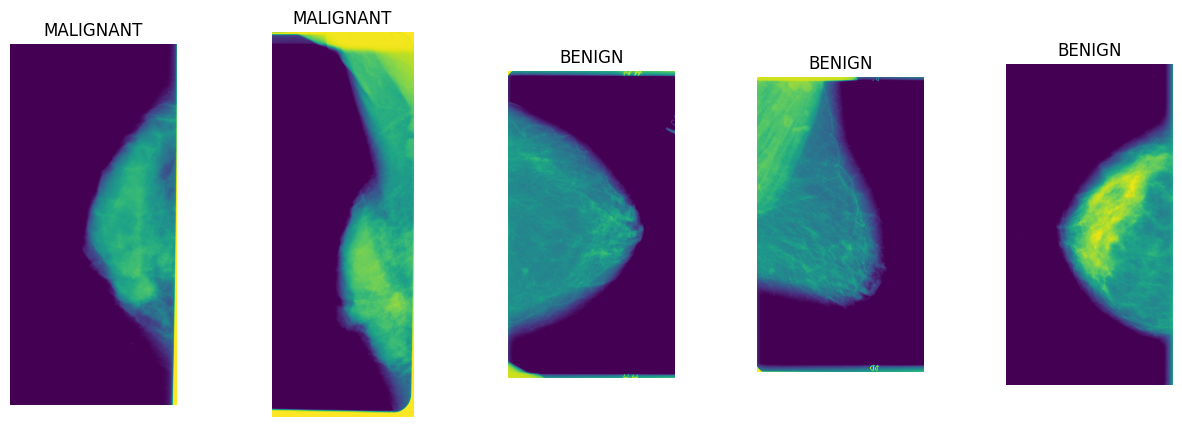

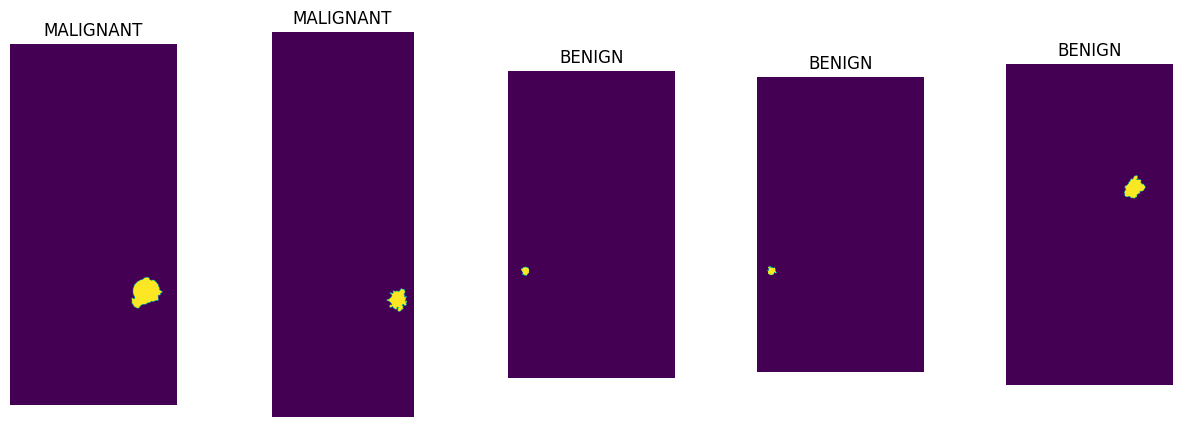

In [6]:
# Function to display images
def display_images(column, number):
    fig, axes = plt.subplots(1, number, figsize=(15, 5))
    fig.subplots_adjust(wspace=0.5)
    
    for i in range(number):
        image_path = mass_test_data.iloc[i][column]
        
        # Comprobamos los paths de lectura
        print(f"Trying to read: {image_path}")
        
        # Mostramos de manera acorde a la extensión
        if image_path.endswith(".dcm"):
            try:
                dicom_data = pydicom.dcmread(image_path)
                image = dicom_data.pixel_array
                pathology = mass_train.iloc[i]["pathology"]
                
                axes[i].imshow(image, cmap="gray")
                axes[i].set_title(pathology)
                axes[i].axis("off")
                
            except (InvalidDicomError, FileNotFoundError) as e:
                print(f"Error en la lectura de la imagen DICOM: {image_path}")
        
        elif image_path.endswith(".jpg"):
            try:
                if os.path.exists(image_path):
                    image = Image.open(image_path)
                    pathology = mass_train.iloc[i]["pathology"]
                    
                    axes[i].imshow(image)
                    axes[i].set_title(pathology)
                    axes[i].axis("off")
                else:
                    print(f"La imagen JPEG no existe: {image_path}")
                    
            except Exception as e:
                print(f"Error en la lectura de la imagen JPEG: {image_path}")
                
        else:
            print(f"No se puede procesar esta extensión: {image_path}")

# Display images
print('Mostramos imágenes:')
display_images('image_file_path', 5)
display_images('ROI_mask_file_path', 5)

In [7]:
# Ahora buscamos cuales son las dimensiones para poder cargarlas y procesarlas

# Función auxiliar para obtener las dimensiones de cada imagen
def get_image_dimensions(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
        return width, height
    except Exception as e:
        print(f"Error opening image {image_path}: {e}")
        return None, None

# Función para obtener todas las dimensiones de un dataset
def load_images_with_dimensions(data):
    # Inicializamos las columnas
    data['roi_width'], data['roi_height'] = None, None
    data['full_width'], data['full_height'] = None, None
    data['cropped_width'], data['cropped_height'] = None, None
    
    for i in range(len(data)):
        # Dimensiones ROI
        roi_path = data.iloc[i, 13]
        roi_width, roi_height = get_image_dimensions(roi_path)
        data.at[i, 'roi_width'] = roi_width
        data.at[i, 'roi_height'] = roi_height
        
        # Dimensiones de la imagen completa
        full_path = data.iloc[i, 11]
        full_width, full_height = get_image_dimensions(full_path)
        data.at[i, 'full_width'] = full_width
        data.at[i, 'full_height'] = full_height
        
        # Dimensiones de la imagen recortada
        cropped_path = data.iloc[i, 12]
        cropped_width, cropped_height = get_image_dimensions(cropped_path)
        data.at[i, 'cropped_width'] = cropped_width
        data.at[i, 'cropped_height'] = cropped_height

    return data

# Aplicamos las funciones
mass_test_dims = load_images_with_dimensions(mass_test_data)
mass_train_dims = load_images_with_dimensions(mass_train_data)

In [15]:
# Creamos summaries con la información para 
width_height_summary = mass_test_data[['roi_width', 'roi_height', 'full_width', 'full_height', 'cropped_width', 'cropped_height']].describe()
print("Resumen de dimensiones:\n",width_height_summary)
print("\n")
mass_test_minimums = mass_test_data[['roi_width', 'roi_height', 'full_width', 'full_height', 'cropped_width', 'cropped_height']].min()
print("Minimos de las imágenes:\n", mass_test_minimums)
print("\n")
mass_test_maxims = mass_test_data[['roi_width', 'roi_height', 'full_width', 'full_height', 'cropped_width', 'cropped_height']].max()
print("Máximos de las imágenes:\n", mass_test_maxims)

Resumen de dimensiones:
         roi_width  roi_height  full_width  full_height  cropped_width  \
count         378         378         378          378            378   
unique        224         172         215          165            243   
top          2896        5491        2896         5491            345   
freq            9          30           9           30              5   

        cropped_height  
count              378  
unique             247  
top                321  
freq                 5  


Minimos de las imágenes:
 roi_width         1789
roi_height        3920
full_width        1846
full_height       3920
cropped_width      145
cropped_height     132
dtype: object


Máximos de las imágenes:
 roi_width         5431
roi_height        6916
full_width        5431
full_height       6916
cropped_width      858
cropped_height     839
dtype: object


In [9]:
# Funcion para adaptar los tamaños
def crop_or_pad_image(image, target_size=(2000, 3000)):
    width, height = image.size
    target_width, target_height = target_size

    # Crop if image is larger than target size
    left = max((width - target_width) // 2, 0)
    top = max((height - target_height) // 2, 0)
    right = min((width + target_width) // 2, width)
    bottom = min((height + target_height) // 2, height)
    image = image.crop((left, top, right, bottom))

    # Convert to RGB if not already in that mode
    if image.mode != "L":
        image = image.convert("L")

    # Pad if image is smaller than target size
    delta_width = max(target_width - image.width, 0)
    delta_height = max(target_height - image.height, 0)
    padding = (delta_width // 2, delta_height // 2, delta_width - delta_width // 2, delta_height - delta_height // 2)
    
    left_padding = delta_width // 2
    top_padding = delta_height // 2
    padded_image = Image.new("L", target_size)
    padded_image.paste(image, (left_padding, top_padding))

    return padded_image

# Funcion para redimensionar las imágenes recortadas
#def resize_cropped_image(image, target_size=(500, 500)):
#    return image.resize(target_size)

# Process and store images as tensors
def process_and_store_images(data):
    roi_tensors, cropped_tensors, full_tensors = [], [], []
    
    for i, row in data.iterrows():
        # Procesamos la imagen ROI
        roi_image = Image.open(row['ROI_mask_file_path'])
        roi_image = crop_or_pad_image(roi_image, target_size=(2000, 3000))
        roi_tensor = torch.tensor(np.array(roi_image)).float() / 255.0
        roi_tensors.append(roi_tensor)
        
        # Procesamos la imagen original
        full_image = Image.open(row['image_file_path'])
        full_image = crop_or_pad_image(full_image, target_size=(2000, 3000))
        full_tensor = torch.tensor(np.array(full_image)).float() / 255.0
        full_tensors.append(full_tensor)
        
        # Procesamos la imagen recortada
        cropped_image = Image.open(row['cropped_image_file_path'])
        cropped_image = crop_or_pad_image(cropped_image, target_size=(500, 500))
        cropped_tensor = torch.tensor(np.array(cropped_image)).float() / 255.0
        cropped_tensors.append(cropped_tensor)

    # Guardamos las imágenes procesadas
    data['roi_tensor'] = roi_tensors
    data['full_tensor'] = full_tensors
    data['cropped_tensor'] = cropped_tensors

    return data

# Ejecutamos la función
mass_test_data2 = process_and_store_images(mass_test_data[0:10].copy())
#mass_train_data = process_and_store_images(mass_train_data)

ROI Masks:


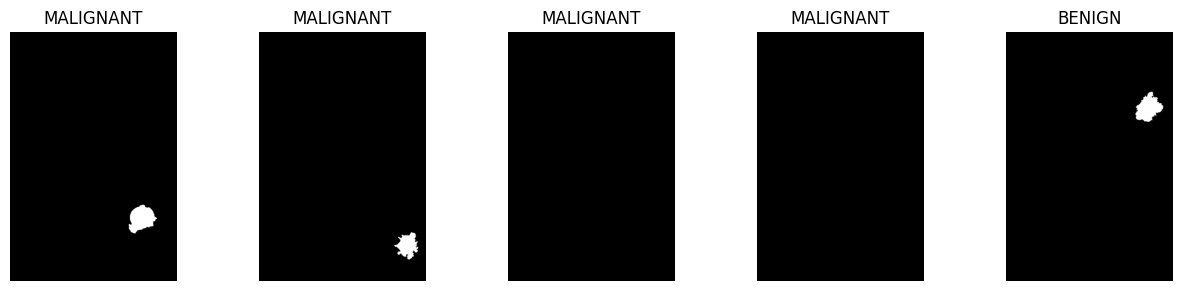

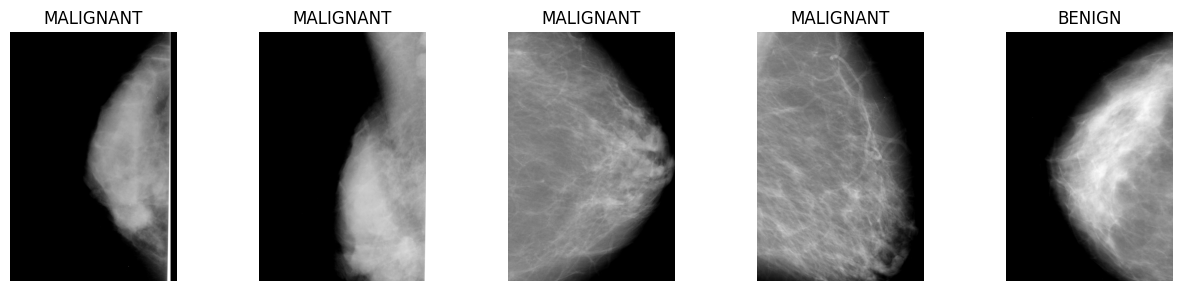

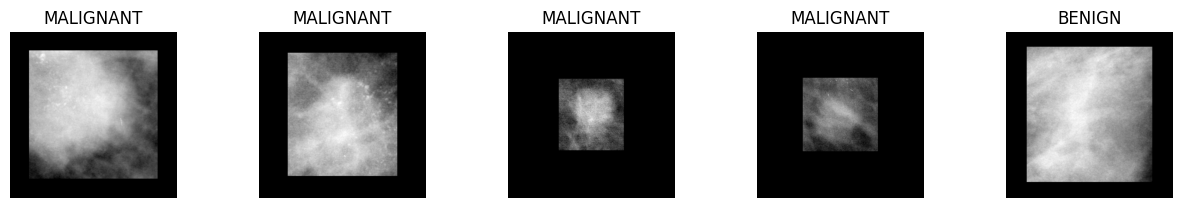

In [11]:
# Mostramos las imágenes 
def display_images(data, tensor_column, number):
    fig, axes = plt.subplots(1, number, figsize=(15, 5))
    fig.subplots_adjust(wspace=0.5)
    
    for i in range(number):
        # Obtenemos la imagen y la etiqueta
        image_tensor = data.iloc[i][tensor_column]
        pathology = data.iloc[i]["pathology"]
        
        # Reconvertimos el tensor a imagen
        image_array = np.array(image_tensor * 255, dtype=np.uint8)
        if image_array.shape[-1] == 3: 
            axes[i].imshow(image_array)
        else:
            axes[i].imshow(image_array, cmap="gray")
        
        # Mostramos el título y quitamos ejes
        axes[i].set_title(pathology)
        axes[i].axis("off")

# Mostramos las imágenes procesadas
print('ROI Masks:')
display_images(mass_test_data2, 'roi_tensor', 5)
display_images(mass_test_data2, 'full_tensor', 5)
display_images(mass_test_data2, 'cropped_tensor', 5)